# Class Activity: "Be the Agent" on CartPole

**Format:** pairs | **Environment:** `rl-gym` conda env | **Duration:** one class session

## Learning goals
- Identify the 4 state variables and the 2 actions.
- Understand the reward and the termination and truncation conditions.
- Build intuition for why a policy is needed before introducing DQN.

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)

## Part 1: Predict before you run 
Inspect the spaces and the outputs of `reset()` and `step()`, then fill in the table below.

In [3]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

obs, info = env.reset(seed=SEED)
print("reset ->", obs, info)

obs, reward, terminated, truncated, info = env.step(0)
print("step(0) ->", obs, reward, terminated, truncated, info)
obs, reward, terminated, truncated, info = env.step(1)
print("step(1) ->", obs, reward, terminated, truncated, info)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
reset -> [ 0.01369617 -0.02302133 -0.04590265 -0.04834723] {}
step(0) -> [ 0.01323574 -0.21745604 -0.04686959  0.22950698] 1.0 False False {}
step(1) -> [ 0.00888662 -0.02169675 -0.04227945 -0.0775841 ] 1.0 False False {}


| Index | Variable | Meaning | Units | Termination limit |
|---|---|---|---|---|
| 0 | Cart position | | | ±2.4 |
| 1 | Cart velocity | | | none |
| 2 | Pole angle | | | ±12° (~0.21 rad) |
| 3 | Pole angular velocity | | | none |

**Questions**
1. What does action 0 do? What does action 1 do?
2. What reward is given per step?
3. When does the episode end?

*Your answers:*
- 
- 
- 

## Part 2: Human agent
Play the game by typing actions (`0` = left, `1` = right). Use a Jupyter-friendly input prompt; press Enter on an empty line to quit.

> Requires a display. If rendering fails, remove `render_mode="human"` and rely on the printed state.

In [4]:
def play_human(seed=0, render=True):
    #env = gym.make("CartPole-v1", render_mode="human" if render else None)
    env = gym.make("CartPole-v1")

    obs, _ = env.reset(seed=seed)
    total, done = 0.0, False
    while not done:
        print(np.round(obs, 3))
        answer = input("0=left, 1=right (Enter to quit): ").strip()
        print("Action:", answer)
        if answer not in ("0", "1"):
            break
        obs, r, terminated, truncated, _ = env.step(int(answer))
        total += r
        done = terminated or truncated
    env.close()
    
    print("Score:", total)

play_human()

[ 0.014 -0.023 -0.046 -0.048]
Action: 1
[ 0.013  0.173 -0.047 -0.355]
Action: 0
[ 0.017 -0.022 -0.054 -0.078]
Action: 1
[ 0.016  0.174 -0.056 -0.387]
Action: 1
[ 0.02   0.37  -0.063 -0.696]
Action: 
Score: 4.0


**Reflection**
- Which variable did you watch most? Which one did you ignore?
- Why is it hard to play with only position information?

*Your answers:*
- 
- 

## Part 3: Design a rule-based policy
A policy is a function `policy(obs) -> action`. Evaluate each over 20 episodes.

In [5]:
def evaluate_policy(policy_fn, n_episodes=20, env_id="CartPole-v1", seed=0, **make_kwargs):
    env = gym.make(env_id, **make_kwargs)
    returns = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        total, done = 0.0, False
        while not done:
            obs, r, terminated, truncated, _ = env.step(policy_fn(obs))
            total += r
            done = terminated or truncated
        returns.append(total)
    env.close()
    return float(np.mean(returns)), float(np.std(returns))

rng = np.random.default_rng(SEED)

def random_policy(obs):
    return int(rng.integers(2))

print("Random baseline (mean, std):", evaluate_policy(random_policy))

Random baseline (mean, std): (22.9, 13.356271934937533)


In [6]:
# obs = [cart_pos, cart_vel, pole_angle, pole_ang_vel]
def policy_angle(obs):
    return 0 if obs[2] < 0 else 1

def policy_ang_vel(obs):
    return 0 if obs[3] < 0 else 1

K = 1.0  # TODO: tune
def policy_combined(obs):
    return 0 if obs[2] + K * obs[3] < 0 else 1

# TODO: write your own policy
def policy_mine(obs):
    raise NotImplementedError

policies = {
    "random": random_policy,
    "angle": policy_angle,
    "angular velocity": policy_ang_vel,
    "angle + k*ang_vel": policy_combined,
}
for name, fn in policies.items():
    mean, std = evaluate_policy(fn)
    print(f"{name:20s} mean={mean:7.1f} std={std:6.1f}")

random               mean=   24.0 std=   8.2
angle                mean=   40.9 std=   7.4
angular velocity     mean=  198.7 std=  36.3
angle + k*ang_vel    mean=  491.7 std=  36.2


| Policy | Variables used | Mean return | Std | Why it works or fails |
|---|---|---|---|---|
| random | none | | | |
| angle | | | | |
| angular velocity | | | | |
| angle + k*ang_vel | | | | |
| my policy | | | | |

## Part 4: Break the environment
Pick **one** experiment and report back to the class.

The cell only prints one initial state. To measure the effect, pass the same options to env.reset() inside evaluate_policy() and compare returns for the default and wide ranges

In [7]:
# Experiment A: larger initial-state noise (default is +/-0.05)
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=SEED, options={"low": -0.3, "high": 0.3})
print("Initial state with larger noise:", obs)
env.close()

Initial state with larger noise: [ 0.08217701 -0.13812797 -0.2754159  -0.2900834 ]


In [9]:
# Experiment B: change termination thresholds
env = gym.make("CartPole-v1")
env.unwrapped.theta_threshold_radians = 0.4  # default ~0.2095
env.unwrapped.x_threshold = 4.8              # default 2.4
obs, _ = env.reset(seed=SEED)
done, steps = False, 0
while not done:
    obs, r, terminated, truncated, _ = env.step(policy_combined(obs))
    steps += 1
    done = terminated or truncated
print("Steps survived:", steps, "| terminated:", terminated, "| truncated:", truncated)
env.close()

Steps survived: 500 | terminated: False | truncated: True


In [10]:
# Experiment C: remove one variable from the policy and observe the degradation
def policy_no_vel(obs):
    return 0 if obs[2] < 0 else 1

print("full policy   :", evaluate_policy(policy_combined))
print("without ang_vel:", evaluate_policy(policy_no_vel))

full policy   : (491.7, 36.178861231387586)
without ang_vel: (40.9, 7.38173421358423)


In [11]:
# Experiment D: CartPole-v0 (200 steps) vs v1 (500 steps): truncation vs termination
for env_id in ("CartPole-v0", "CartPole-v1"):
    print(env_id, evaluate_policy(policy_combined, env_id=env_id))

/home/rolando/Research/Dev/anaconda3/envs/rl-gym/lib/python3.10/site-packages/gymnasium/envs/registration.py:519: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


CartPole-v0 (200.0, 0.0)
CartPole-v1 (491.7, 36.178861231387586)


*Experiment chosen and findings:*

- 

## Part 5: Debrief and bridge to DQN
Discuss:
- Which variables were most informative? Why does angular velocity matter more than position?
- Why can't we use a table (Q-learning) directly? (The state is continuous.)
- What would a neural network need as input and output? (4 inputs, 2 Q-values.)

## Deliverable
A short worksheet containing the filled variable table, the policy comparison table, and a 3-sentence explanation of why the best policy worked.

*Explanation (3 sentences):*

- 

## Optional extensions

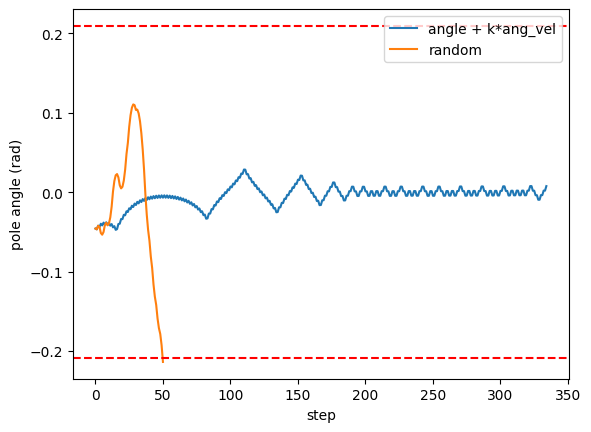

In [12]:
# Plot pole angle vs time for a good and a bad policy
def angle_trace(policy_fn, seed=0):
    env = gym.make("CartPole-v1")
    obs, _ = env.reset(seed=seed)
    angles, done = [obs[2]], False
    while not done:
        obs, _, terminated, truncated, _ = env.step(policy_fn(obs))
        angles.append(obs[2])
        done = terminated or truncated
    env.close()
    return angles

plt.plot(angle_trace(policy_combined), label="angle + k*ang_vel")
plt.plot(angle_trace(random_policy), label="random")
plt.axhline(0.2095, color="r", ls="--")
plt.axhline(-0.2095, color="r", ls="--")
plt.xlabel("step")
plt.ylabel("pole angle (rad)")
plt.legend()
plt.show()

In [13]:
# Q-table size if each variable is discretized into N bins
n_bins = 10  # TODO: try other values
n_states = n_bins ** 4
n_actions = 2
print(f"{n_bins} bins/variable -> {n_states:,} states x {n_actions} actions = {n_states * n_actions:,} Q-values")

10 bins/variable -> 10,000 states x 2 actions = 20,000 Q-values
